In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [5]:
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

In [6]:
# Plot styling

In [7]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

In [8]:
df=pd.read_csv(r"D:\DATA ANALYSIS\E-commerce Funnel & RFM\Data\cleaned\online_retail_clean.csv", parse_dates=['InvoiceDate'])
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.00
...,...,...,...,...,...,...,...,...,...
776619,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France,10.20
776620,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,12.60
776621,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,16.60
776622,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,16.60


In [9]:
print("Shape:",df.shape)

Shape: (776624, 9)


In [10]:
print("\n Date range:",df['InvoiceDate'].min(),"to",df['InvoiceDate'].max())


 Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00


In [11]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


In [12]:
total_revenue=df['TotalPrice'].sum()
total_orders=df['Invoice'].nunique()
total_customers=df['Customer ID'].nunique()
total_products=df['StockCode'].nunique()
avg_order_value=total_revenue/total_orders

print("=" * 50)
print("BUSINESS SNAPSHOT")
print("=" * 50)
print(f"Total Revenue:        £{total_revenue:,.2f}")
print(f"Total Orders:         {total_orders:,}")
print(f"Total Customers:      {total_customers:,}")
print(f"Total Products:       {total_products:,}")
print(f"Average Order Value:  £{avg_order_value:,.2f}")
print(f"Avg Revenue/Customer: £{total_revenue / total_customers:,.2f}")
print("=" * 50)

BUSINESS SNAPSHOT
Total Revenue:        £17,073,078.29
Total Orders:         36,639
Total Customers:      5,861
Total Products:       4,624
Average Order Value:  £465.98
Avg Revenue/Customer: £2,913.00


In [13]:
#Revenue Over Time (Monthly Trend)

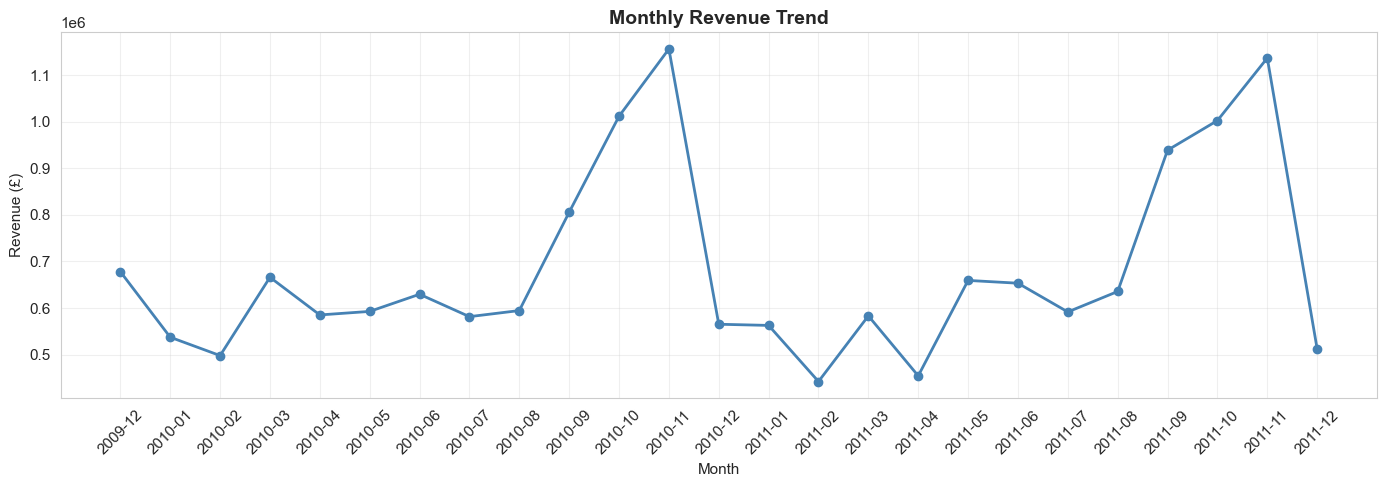

Highest revenue month: 2010-11
Lowest revenue month:  2011-02


In [15]:
df['YearMonth']=df['InvoiceDate'].dt.to_period('M').astype(str)

monthly_revenue=df.groupby('YearMonth')['TotalPrice'].sum().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(monthly_revenue['YearMonth'], monthly_revenue['TotalPrice'],
         marker='o', linewidth=2, color='steelblue')
plt.title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Highest revenue month: {monthly_revenue.loc[monthly_revenue['TotalPrice'].idxmax(), 'YearMonth']}")
print(f"Lowest revenue month:  {monthly_revenue.loc[monthly_revenue['TotalPrice'].idxmin(), 'YearMonth']}")

In [16]:
#Top 10 countries by Revenue

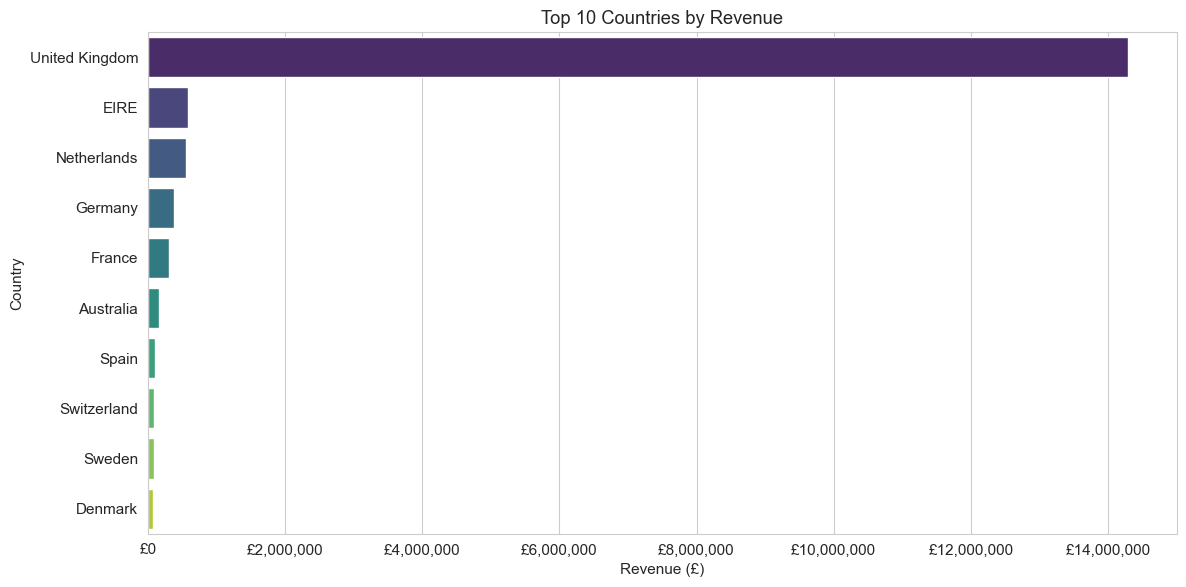

In [24]:
from matplotlib.ticker import FuncFormatter

country_revenue=df.groupby("Country")['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=country_revenue.values,y=country_revenue.index,palette='viridis')
plt.title('Top 10 Countries by Revenue')
plt.xlabel("Revenue (£)")

plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"£{x:,.0f}"))

plt.ylabel('Country')
plt.tight_layout()
plt.show()

In [25]:
# Percentage from UK
uk_revenue=df[df['Country']=='United Kingdom']['TotalPrice'].sum()
print(f'UK Revenue: £{uk_revenue:,.2f} ({uk_revenue/total_revenue*100:.2f}% of total Revenue)')

UK Revenue: £14,291,209.55 (83.71% of total Revenue)


In [ ]:
#Top 10 Products by Revenue

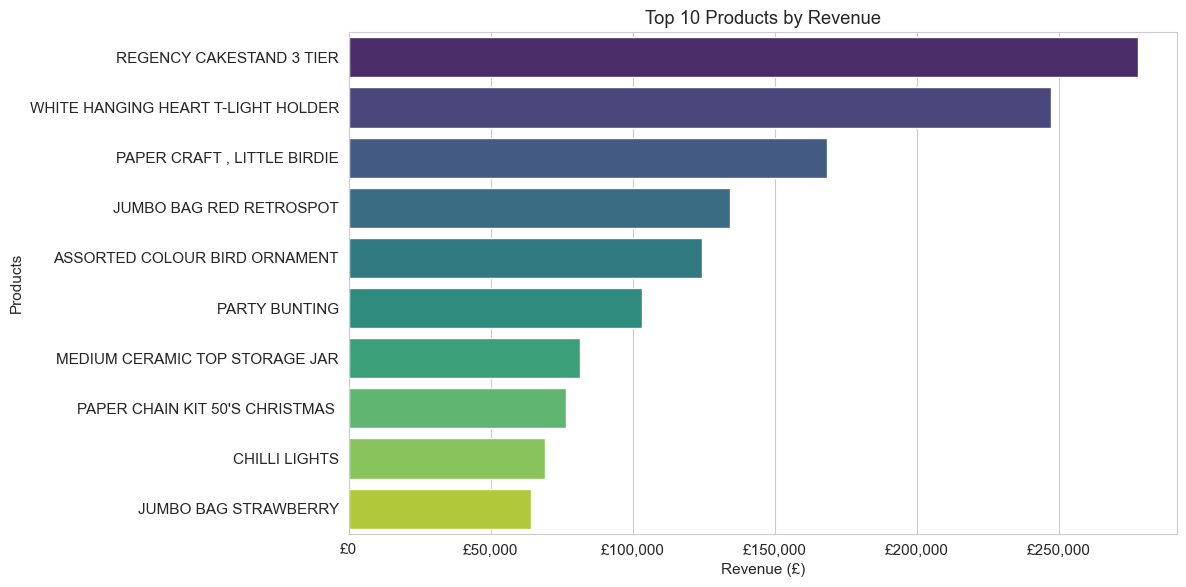

In [27]:
from matplotlib.ticker import FuncFormatter

top_products=df.groupby("Description")['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_products.values,y=top_products.index,palette='viridis')
plt.title('Top 10 Products by Revenue')
plt.xlabel("Revenue (£)")

plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"£{x:,.0f}"))

plt.ylabel('Products')
plt.tight_layout()
plt.show()

In [32]:
#Top 10 Products by Quantity Sold

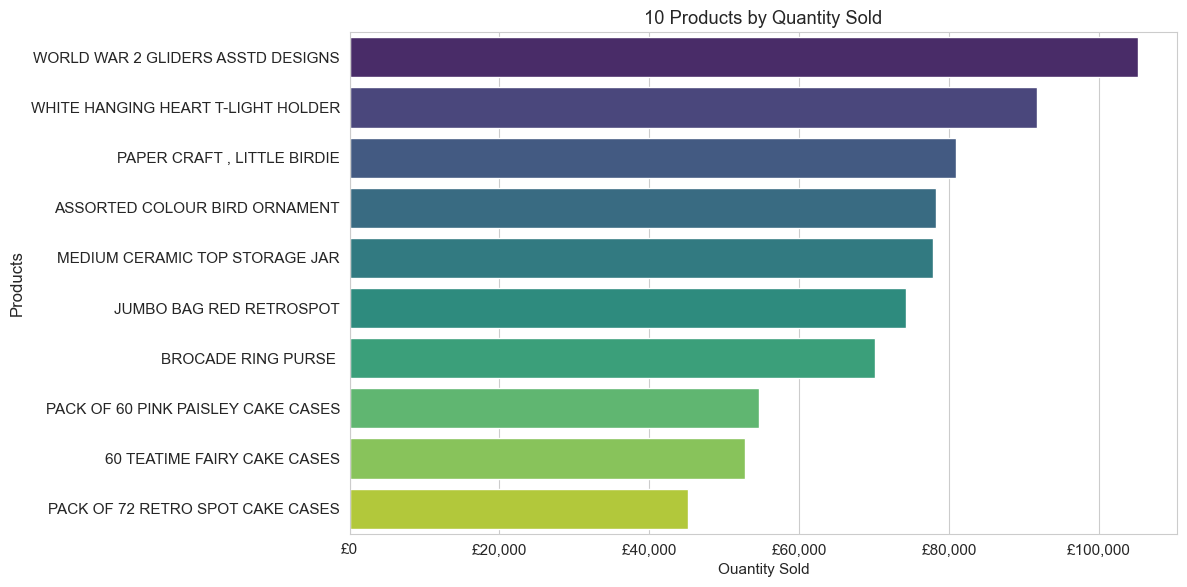

In [30]:
from matplotlib.ticker import FuncFormatter

top_qty=df.groupby("Description")['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_qty.values,y=top_qty.index,palette='viridis')
plt.title('10 Products by Quantity Sold')
plt.xlabel("Ouantity Sold")

plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"£{x:,.0f}"))

plt.ylabel('Products', fontsize=12)
plt.tight_layout()
plt.show()

In [31]:
#Order Value Distribution

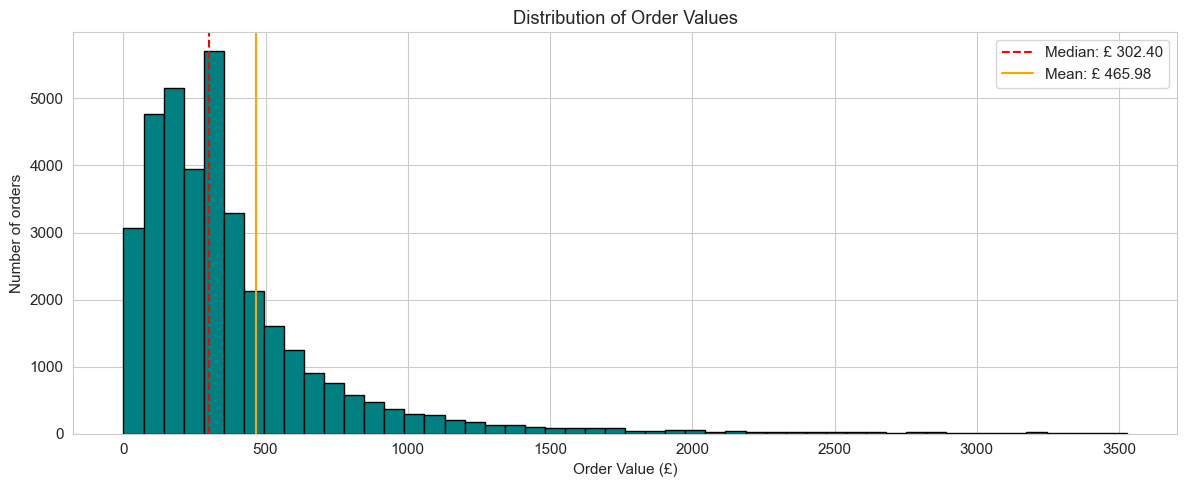

Median Order Value: £ 302.40
Mean Order Value: £ 465.98
Max Order Value: £ 168469.60


In [37]:
order_values=df.groupby('Invoice')['TotalPrice'].sum()

plt.figure(figsize=(12,5))
plt.hist(order_values[order_values <= order_values.quantile(0.99)],bins=50,color='teal',edgecolor='black')
plt.title("Distribution of Order Values")
plt.xlabel('Order Value (£)')
plt.ylabel('Number of orders')

plt.axvline(order_values.median(),color='red',linestyle='--',label=f'Median: £ {order_values.median():.2f}')
plt.axvline(order_values.mean(),color='Orange',linestyle='-',label=f'Mean: £ {order_values.mean():.2f}')

plt.legend()
plt.tight_layout()
plt.show()

print(f'Median Order Value: £ {order_values.median():.2f}')
print(f'Mean Order Value: £ {order_values.mean():.2f}')
print(f'Max Order Value: £ {order_values.max():.2f}')

In [58]:
print("Order values are strongly right-skewed: the median order value is £302.40, the mean is £465.98, and the £168,469.60 maximum indicates a few extreme high-value orders.")

Order values are strongly right-skewed: the median order value is £302.40, the mean is £465.98, and the £168,469.60 maximum indicates a few extreme high-value orders.


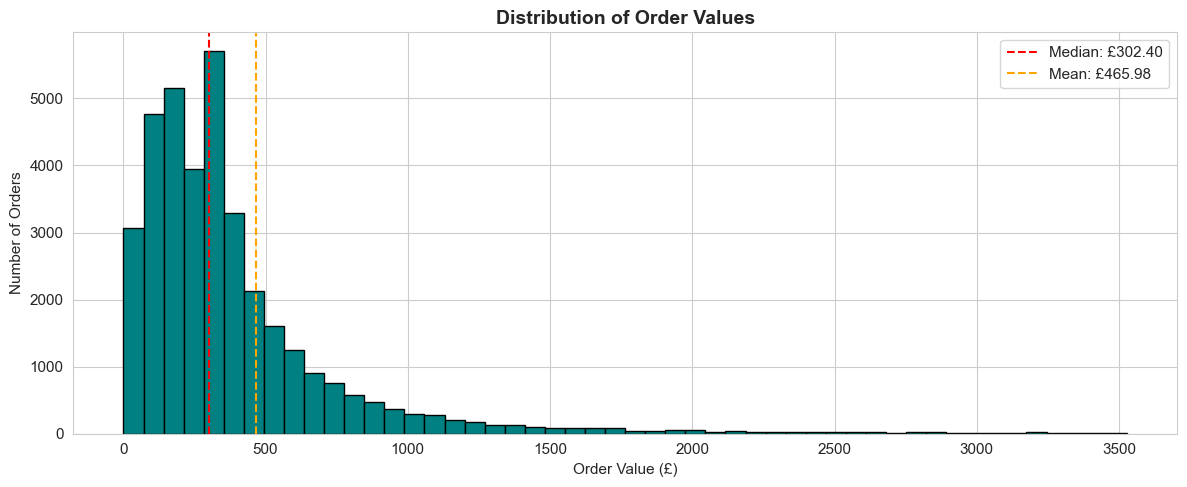

Median Order Value: £302.40
Mean Order Value:   £465.98
Max Order Value:    £168469.60


In [38]:
# Calculate order-level values
order_values = df.groupby('Invoice')['TotalPrice'].sum()

plt.figure(figsize=(12, 5))
plt.hist(order_values[order_values <= order_values.quantile(0.99)], bins=50, color='teal', edgecolor='black')
plt.title('Distribution of Order Values', fontsize=14, fontweight='bold')
plt.xlabel('Order Value (£)')
plt.ylabel('Number of Orders')
plt.axvline(order_values.median(), color='red', linestyle='--', label=f'Median: £{order_values.median():.2f}')
plt.axvline(order_values.mean(), color='orange', linestyle='--', label=f'Mean: £{order_values.mean():.2f}')
plt.legend()
plt.tight_layout()

plt.show()

print(f"Median Order Value: £{order_values.median():.2f}")
print(f"Mean Order Value:   £{order_values.mean():.2f}")
print(f"Max Order Value:    £{order_values.max():.2f}")

In [ ]:
#Purchases Per Customer

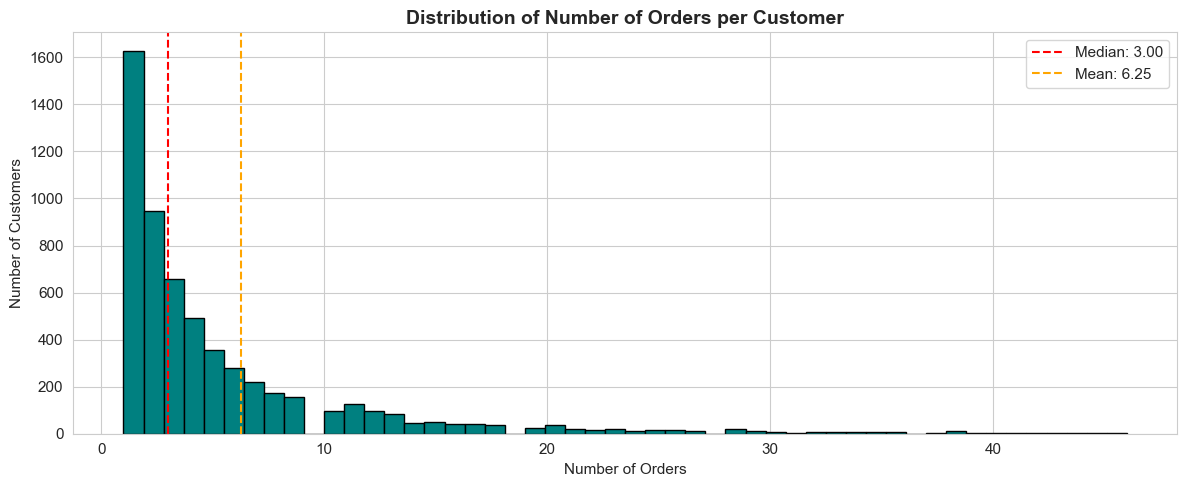

Median orders per customer: 3.00
Mean orders per customer: 6.25
Max orders per customer: 376.00


In [56]:
# Calculate order-level values
customer_orders = df.groupby('Customer ID')['Invoice'].nunique()

plt.figure(figsize=(12, 5))
plt.hist(customer_orders[customer_orders <= customer_orders.quantile(0.99)], bins=50, color='teal', edgecolor='black')
plt.title('Distribution of Number of Orders per Customer', fontsize=14, fontweight='bold')
plt.xlabel('Number of Orders')
plt.ylabel('Number of Customers')
plt.axvline(customer_orders.median(), color='red', linestyle='--', label=f'Median: {customer_orders.median():.2f}')
plt.axvline(customer_orders.mean(), color='orange', linestyle='--', label=f'Mean: {customer_orders.mean():.2f}')
plt.legend()
plt.tight_layout()

plt.show()

print(f"Median orders per customer: {customer_orders.median():.2f}")
print(f"Mean orders per customer: {customer_orders.mean():.2f}")
print(f"Max orders per customer: {customer_orders.max():.2f}")

In [40]:
# One-time vs repeat customers

In [41]:
one_time=(customer_orders==1).sum()
repeat=(customer_orders>1).sum()
print(f"\nOne-time customers: {one_time:,} ({one_time/len(customer_orders)*100:.2f}%)")
print(f"Repeat customers:   {repeat:,} ({repeat/len(customer_orders)*100:.2f}%)")


One-time customers: 1 (0.00%)
Repeat customers:   36,621 (99.95%)


In [57]:
print("Customer retention is extremely high: 99.95% of customers are repeat buyers, while only 0.00% are one-time customers, indicating very strong repeat-purchase behavior.")

Customer retention is extremely high: 99.95% of customers are repeat buyers, while only 0.00% are one-time customers, indicating very strong repeat-purchase behavior.


In [42]:
#Customer Revenue Concentration

In [43]:
customer_revenue=df.groupby('Customer ID')['TotalPrice'].sum().sort_values(ascending=False)

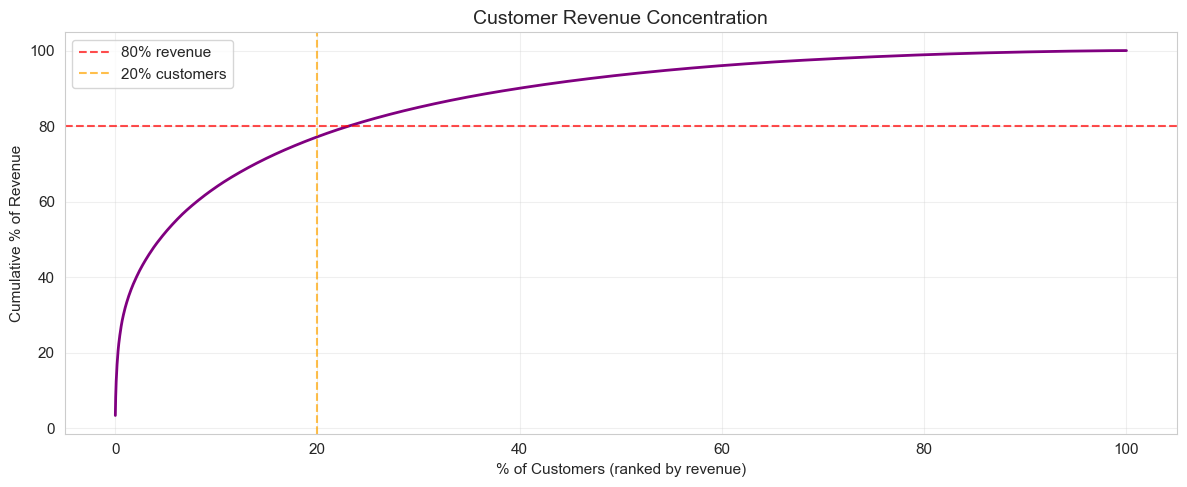

Approximately 22–23% of customers generate 80% of revenue, while the top 20% generate approximately 77–78% of revenue.


In [48]:
# Cumulative revenue by customer rank
cumulative_pct=customer_revenue.cumsum()/customer_revenue.sum()*100
customer_pct=np.arange(1,len(customer_revenue)+1)/len(customer_revenue)*100

plt.figure(figsize=(12, 5))
plt.plot(customer_pct, cumulative_pct, color='purple', linewidth=2)
plt.axhline(80, color='red', linestyle='--', alpha=0.7, label='80% revenue')
plt.axvline(20, color='orange', linestyle='--', alpha=0.7, label='20% customers')
plt.title('Customer Revenue Concentration',fontsize=14)
plt.xlabel('% of Customers (ranked by revenue)')
plt.ylabel('Cumulative % of Revenue')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [49]:
print("Approximately 22–23% of customers generate 80% of revenue, while the top 20% generate approximately 77–78% of revenue.")

Approximately 22–23% of customers generate 80% of revenue, while the top 20% generate approximately 77–78% of revenue.


In [59]:
#Average Order Value by Country (Top 10)

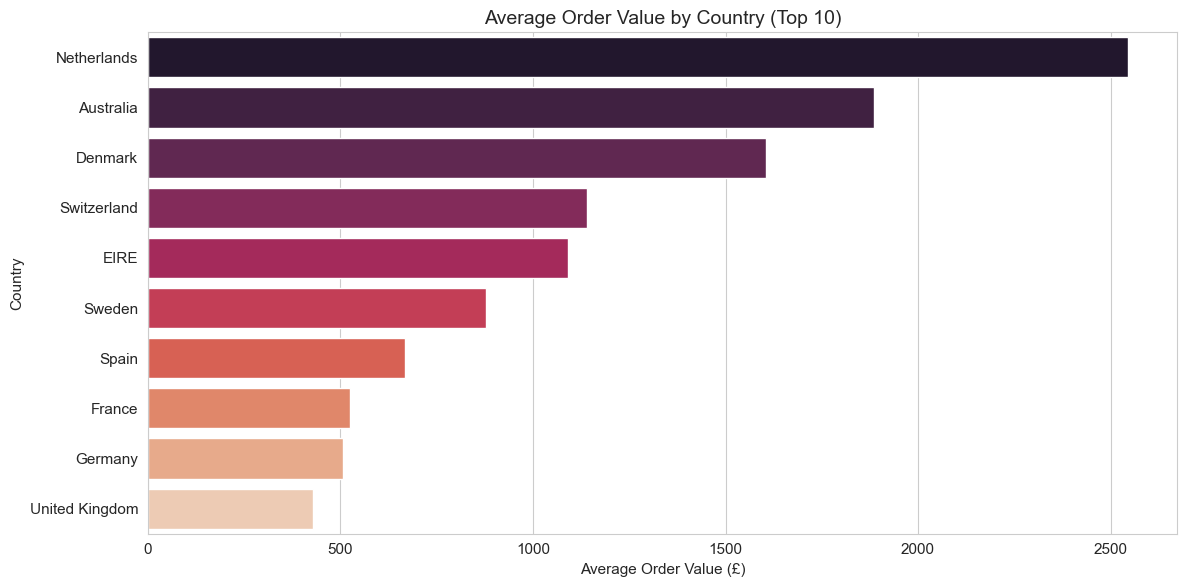

In [60]:
top_countries = df.groupby('Country')['TotalPrice'].sum().nlargest(10).index
country_aov = (df[df['Country'].isin(top_countries)].groupby('Country').apply(lambda x: x['TotalPrice'].sum() / x['Invoice'].nunique()).sort_values(ascending=False).reset_index(name='AOV'))

plt.figure(figsize=(12, 6))
sns.barplot(data=country_aov, x='AOV', y='Country', palette='rocket')
plt.title('Average Order Value by Country (Top 10)', fontsize=14)
plt.xlabel('Average Order Value (£)')
plt.tight_layout()
plt.show()

In [61]:
#EDA Summary

In [62]:
print("=" * 60)
print("EDA KEY FINDINGS SUMMARY")
print("=" * 60)


print(f"\n1.BUSINESS SCALE")
print(f"   - Revenue: £{df['TotalPrice'].sum():,.2f}")
print(f"   - Customers: {df['Customer ID'].nunique():,}")
print(f"   - Orders: {df['Invoice'].nunique():,}")


print(f"\n2. GEOGRAPHY")
uk_pct = df[df['Country'] == 'United Kingdom']['TotalPrice'].sum() / df['TotalPrice'].sum() * 100
print(f"   - UK accounts for {uk_pct:.1f}% of revenue")

print(f"\n3. CUSTOMER BEHAVIOR")
one_time_pct = (customer_orders == 1).sum() / len(customer_orders) * 100
print(f"   - {one_time_pct:.1f}% of customers buy only once")
print(f"   - Median orders per customer: {customer_orders.median()}")

print(f"\n4. REVENUE CONCENTRATION")
top_20_pct_calc = int(len(customer_revenue) * 0.2)
top_20_rev = customer_revenue.iloc[:top_20_pct_calc].sum() / customer_revenue.sum() * 100
print(f"   - Top 20% of customers = {top_20_rev:.1f}% of revenue")


print(f"\n5. ORDER VALUES")
print(f"   - Median order value: £{order_values.median():.2f}")
print(f"   - Mean order value:   £{order_values.mean():.2f}")
print(f"   - (Mean > Median = right-skewed, some large orders)")

print("=" * 60)

EDA KEY FINDINGS SUMMARY

1.BUSINESS SCALE
   - Revenue: £17,073,078.29
   - Customers: 5,861
   - Orders: 36,639

2. GEOGRAPHY
   - UK accounts for 83.7% of revenue

3. CUSTOMER BEHAVIOR
   - 27.7% of customers buy only once
   - Median orders per customer: 3.0

4. REVENUE CONCENTRATION
   - Top 20% of customers = 77.2% of revenue

5. ORDER VALUES
   - Median order value: £302.40
   - Mean order value:   £465.98
   - (Mean > Median = right-skewed, some large orders)
